# Chương 6: Transformer

Transformer là kiến trúc cách mạng hóa NLP và AI hiện đại. Ba điểm khác biệt so với RNN/CNN:
1. **Không dùng recurrence hay convolution** — chỉ dùng attention và FFN
2. **Self-attention** — mô hình hóa trực tiếp phụ thuộc toàn cục giữa mọi cặp từ
3. **Rất linh hoạt** — dễ thích nghi với nhiều task khác nhau

---

# 6.1 Mô Hình Cơ Bản

---

## 6.1.1 Kiến Trúc Transformer

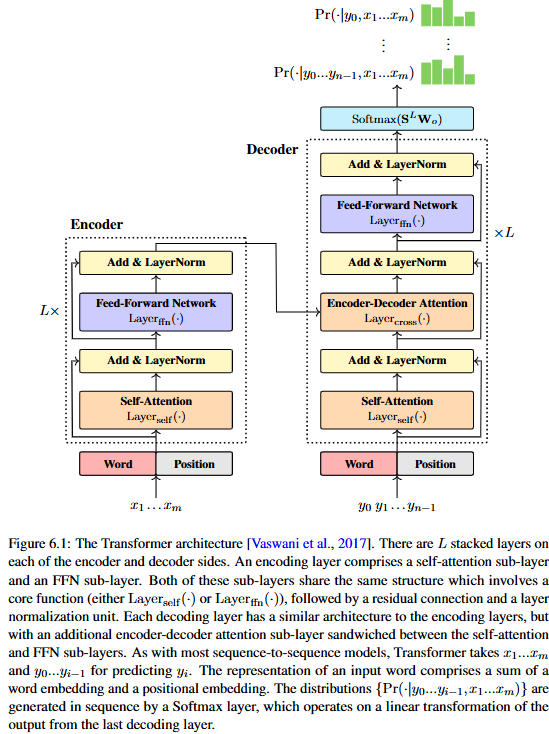

### Encoder

Gồm $L$ lớp xếp chồng. Mỗi **encoding layer** có **hai sub-layers**:

**Sub-layer 1 — Self-Attention:**

$$C = \text{Att}_{\text{self}}(H) \tag{6.1}$$

$$H_{\text{self}} = \text{LNorm}(C + H) \tag{6.2}$$

$$\text{Layer}_{\text{self}}(H) = \text{LNorm}(\text{Att}_{\text{self}}(H) + H) \tag{6.3}$$

**Sub-layer 2 — Feed-Forward Network:**

$$\text{Layer}_{\text{ffn}}(H_{\text{self}}) = \text{LNorm}(\text{FFN}(H_{\text{self}}) + H_{\text{self}}) \tag{6.4}$$

$\text{FFN}(\cdot)$ thường là **two-layer network với ReLU**: $\text{FFN}(x) = \text{ReLU}(xW_1 + b_1)W_2 + b_2$.

**Xếp chồng $L$ lớp:**

$$H^l_{\text{self}} = \text{Layer}_{\text{self}}(H^{l-1}) \tag{6.6}$$
$$H^l = \text{Layer}_{\text{ffn}}(H^l_{\text{self}}) \tag{6.5}$$

$H^0$ = input embeddings; $H^L$ = final encoder output.

### Decoder

Gồm $L$ lớp, mỗi **decoding layer** có **ba sub-layers**:

$$S^l_{\text{self}} = \text{Layer}_{\text{self}}(S^{l-1}) \tag{6.9}$$
$$S^l_{\text{cross}} = \text{Layer}_{\text{cross}}(H^L, S^l_{\text{self}}) \tag{6.8}$$
$$S^l = \text{Layer}_{\text{ffn}}(S^l_{\text{cross}}) \tag{6.7}$$

**Ba sub-layers:**
- **Self-attention:** Decoder attend vào chính mình (target sequence đã sinh)
- **Cross-attention:** Decoder attend vào encoder output $H^L$ (source sequence)
- **FFN:** Biến đổi phi tuyến

**Output layer:**

$$O = S^L \cdot W_o, \quad W_o \in \mathbb{R}^{d \times |V_y|} \tag{6.10}$$

$$\begin{pmatrix}\Pr(\cdot|y_0, x)\\\vdots\\\Pr(\cdot|y_0\ldots y_{n-1}, x)\end{pmatrix} = \text{Softmax}(O) \tag{6.11}$$

$$\log\Pr(y|x) = \sum_{i=1}^n \log\Pr(y_i|y_0\ldots y_{i-1}, x) \tag{6.12}$$

### Ba Biến Thể Kiến Trúc

| Biến thể | Thành phần | Ứng dụng |
|---|---|---|
| **Encoder-only** | Chỉ encoder | BERT — hiểu ngôn ngữ |
| **Decoder-only** | Chỉ decoder | GPT — sinh ngôn ngữ |
| **Encoder-Decoder** | Cả hai | T5, machine translation |

---

## 6.1.2 Positional Encoding

**Vấn đề:** Attention và FFN đều **bất biến với thứ tự** (permutation invariant) → cần thêm thông tin vị trí tường minh.

**Giải pháp — cộng positional encoding vào word embedding:**

$$e_j = x_j + \text{PE}(j) \tag{6.13}$$

**Sinusoidal PE (Vaswani et al., 2017):**

$$\text{PE}(i, 2k) = \sin\!\left(\frac{i}{10000^{2k/d}}\right) \tag{6.14}$$

$$\text{PE}(i, 2k+1) = \cos\!\left(\frac{i}{10000^{2k/d}}\right) \tag{6.15}$$

- Chiều chẵn: sin với tần số cao → thay đổi nhanh theo $i$
- Chiều lẻ: cos với tần số thấp → thay đổi chậm
- Tổng thể: biểu diễn vị trí như hệ số đếm liên tục, đa tần số

**Input của encoder:**

$$H^0 = \begin{pmatrix}e_1\\\vdots\\e_m\end{pmatrix} \tag{6.16}$$

---

## 6.1.3 Multi-head Self-attention

### Self-attention Cơ Bản

**Ý tưởng:** Mỗi vị trí $i$ trong chuỗi **attend trực tiếp vào mọi vị trí khác** → representation $c_i$ là tổ hợp có trọng số của toàn bộ input:

$$c_i = \sum_{j=1}^m \alpha_{i,j} h_j \tag{6.17}$$

$$\alpha_{i,j} = \text{Softmax}\!\left(\frac{h_i h_j^\top}{\sqrt{d}}\right) = \frac{\exp(h_i h_j^\top/\sqrt{d})}{\sum_k \exp(h_i h_k^\top/\sqrt{d})} \tag{6.18}$$

**Tại sao chia $\sqrt{d}$?** Khi $d$ lớn, dot-product có variance lớn → gradient vanish trong Softmax. Chia $\sqrt{d}$ giữ variance ổn định.

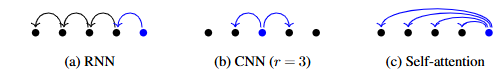

**Ưu điểm so với RNN/CNN:** Self-attention rút ngắn "khoảng cách tính toán" giữa hai vị trí xuống còn $O(1)$ — không cần đi qua nhiều bước trung gian như RNN.

### QKV Self-attention

Tổng quát hóa qua linear projections:

$$H^q = HW^q, \quad H^k = HW^k, \quad H^v = HW^v \tag{6.21-6.23}$$

với $W^q, W^k, W^v \in \mathbb{R}^{d \times d}$.

$$C = \text{Att}_{\text{self}}(H) = \text{Softmax}\!\left(\frac{H^q [H^k]^\top}{\sqrt{d}}\right) H^v \tag{6.24}$$

$\text{Softmax}(\cdot)$ row-wise → ma trận $m \times m$ attention weights:

$$\text{row}_i = [\alpha_{i,1},\ldots,\alpha_{i,m}] \tag{6.25}$$

Mỗi hàng là phân phối attention của vị trí $i$ trên toàn chuỗi.

### Multi-head Self-attention

**Ý tưởng:** Attention trong **một** không gian có thể bỏ sót các loại quan hệ khác nhau. Dùng **$\tau$ heads song song trong $\tau$ subspaces** để học nhiều loại quan hệ cùng lúc (cú pháp, ngữ nghĩa, coreference,...).

**Quy trình** với $\tau$ heads, mỗi head có chiều $d/\tau$:

**Project vào subspace $h$:**

$$H^q_h = HW^q_h, \quad H^k_h = HW^k_h, \quad H^v_h = HW^v_h \quad W^q_h, W^k_h, W^v_h \in \mathbb{R}^{d \times d/\tau} \tag{6.29-6.31}$$

**Attention từng head:**

$$C_{\text{head}_h} = \text{Softmax}\!\left(\frac{H^q_h [H^k_h]^\top}{\sqrt{d/\tau}}\right) H^v_h \in \mathbb{R}^{m \times d/\tau} \tag{6.28}$$

**Merge và project về chiều gốc:**

$$C = \text{Merge}(C_{\text{head}_1},\ldots,C_{\text{head}_\tau}) \cdot W^c, \quad W^c \in \mathbb{R}^{d \times d} \tag{6.26}$$

```
Input H ∈ ℝ^{m×d}
  ↓ Project × τ heads
H^q_h, H^k_h, H^v_h ∈ ℝ^{m×(d/τ)}  (với mỗi head h)
  ↓ Scaled dot-product attention × τ (song song)
C_{head_h} ∈ ℝ^{m×(d/τ)}
  ↓ Concatenate
[C_{head_1}|...|C_{head_τ}] ∈ ℝ^{m×d}
  ↓ Linear projection W^c
C ∈ ℝ^{m×d}
```

**Đặc điểm quan trọng:**
- Tổng số tham số tương đương single-head ($d^2$) — không tăng thêm tham số đáng kể
- Chạy **song song hoàn toàn** trên hardware
- Mỗi head có thể học loại quan hệ khác nhau

---

## Tổng Kết Mục 6.1 (phần đầu)

```
Transformer Encoder Layer:
  H → Self-Attention → + H → LayerNorm → Hself
  Hself → FFN → + Hself → LayerNorm → H_out
  
Transformer Decoder Layer:
  S → Self-Attention (masked) → + S → LN → S_self
  S_self + H^L → Cross-Attention → + S_self → LN → S_cross
  S_cross → FFN → + S_cross → LN → S_out

Input = Word Embedding + Positional Encoding
  ej = xj + PE(j)
  PE(i,2k) = sin(i/10000^{2k/d})  (sinusoidal)

Multi-head Self-attention:
  C = Merge(Att(HWq_h, HWk_h, HWv_h)) · Wc
  τ heads song song, mỗi head chiều d/τ
```

| Thành phần | Vai trò | Đặc điểm |
|---|---|---|
| Self-attention | Capture global dependencies | $O(1)$ path length |
| Cross-attention | Source ↔ Target coupling | Encoder output làm K,V |
| FFN | Non-linear transformation | Position-wise độc lập |
| Residual + LNorm | Gradient flow, ổn định training | Add & Normalize |
| Positional Encoding | Thêm thông tin vị trí | Sinusoidal hoặc learnable |

Bạn gửi tiếp phần còn lại của 6.1 nhé!

# 6.1 Mô Hình Cơ Bản (tiếp theo)

---

## 6.1.4 Layer Normalization

**Mục đích:** Chuẩn hóa activations trong từng lớp → training ổn định hơn.

$$\text{LNorm}(h) = \alpha \odot \frac{h - \mu}{\sigma + \varepsilon} + \beta \tag{6.32}$$

$$\mu = \frac{1}{d}\sum_{k=1}^d h_k, \quad \sigma = \sqrt{\frac{1}{d}\sum_{k=1}^d (h_k - \mu)^2} \tag{6.33, 6.34}$$

- $\mu, \sigma$: scalar mean và std tính **trên toàn chiều $d$** của một vector (khác Batch Norm tính trên batch)
- $\alpha, \beta \in \mathbb{R}^d$: scale và shift — tham số học được
- $\varepsilon$: nhỏ để tránh chia cho 0

**Ví dụ tính toán** ($m=4$, $d=3$, $\alpha=1$, $\beta=0$, $\varepsilon=0.1$):

$$\begin{pmatrix}1&1&2\\0.9&0.9&0\\0.7&0.8&0\\3&1&7\end{pmatrix} \xRightarrow{\text{LNorm}} \begin{pmatrix}-0.5&-0.5&1.2\\0.6&0.6&-1.2\\0.4&1.0&-1.0\\-0.27&-1.04&1.27\end{pmatrix}$$

Mỗi hàng chuẩn hóa độc lập với mean/std riêng của hàng đó.

### Post-norm vs Pre-norm

**Post-norm** (Vaswani et al., 2017 gốc) — LNorm sau residual:

$$H_{\text{out}} = \text{LNorm}(F(H_{\text{in}}) + H_{\text{in}}) \tag{6.35}$$

**Pre-norm** — LNorm trước core function:

$$H_{\text{out}} = F(\text{LNorm}(H_{\text{in}})) + H_{\text{in}} \tag{6.36}$$

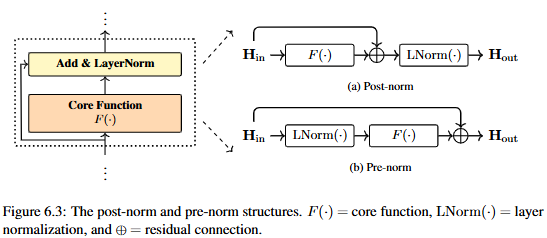

| | Post-norm | Pre-norm |
|---|---|---|
| **Training** | Khó hơn với mạng rất sâu | Ổn định hơn, dễ train |
| **Biểu diễn** | Mạnh hơn (không phụ thuộc residual nhiều) | Phụ thuộc residual hơn |
| **Dùng trong** | Transformer gốc | GPT-3, LLaMA và các LLM hiện đại |

---

## 6.1.5 Feed-forward Neural Networks

**Cấu trúc two-layer FFN với ReLU:**

$$H_{\text{hidden}} = \text{ReLU}(H_{\text{in}} W_h + b_h) \tag{6.38}$$

$$H_{\text{out}} = H_{\text{hidden}} W_f + b_f \tag{6.37}$$

với $W_h \in \mathbb{R}^{d \times d_{\text{ffn}}}$, $W_f \in \mathbb{R}^{d_{\text{ffn}} \times d}$, thường $d_{\text{ffn}} = 4d$.

**FFN hoạt động position-wise** — áp dụng cùng một FFN độc lập cho từng vị trí trong chuỗi → có thể song song hoàn toàn.

**Độ phức tạp tham số và thời gian:**

| Sub-model | # Tham số | Time Complexity | Số lần dùng |
|---|---|---|---|
| **Encoder Self-attention** | $4d^2$ | $O(m^2 d)$ | $L$ |
| **Encoder FFN** | $2d\cdot d_{\text{ffn}} + d + d_{\text{ffn}}$ | $O(m \cdot d \cdot d_{\text{ffn}})$ | $L$ |
| **Decoder Self-attention** | $4d^2$ | $O(n^2 d)$ | $L$ |
| **Decoder Cross-attention** | $4d^2$ | $O(mn \cdot d)$ | $L$ |
| **Decoder FFN** | $2d\cdot d_{\text{ffn}} + d + d_{\text{ffn}}$ | $O(n \cdot d \cdot d_{\text{ffn}})$ | $L$ |

> **Nhận xét quan trọng:** Khi $d_{\text{ffn}}$ lớn, **FFN chiếm đa số tham số** của Transformer — đây là vấn đề cần giải quyết khi scale lên mô hình rất lớn (xem Mục 6.3).

---

## 6.1.6 Decoder-side Attention

### Cross-attention

Decoder attend vào encoder output $H_{\text{enc}}$ — **queries từ decoder, keys/values từ encoder**:

$$S^q_{\text{self}} = S_{\text{self}} W^q_{\text{cross}}, \quad H^k_{\text{enc}} = H_{\text{enc}} W^k_{\text{enc}}, \quad H^v_{\text{enc}} = H_{\text{enc}} W^v_{\text{enc}} \tag{6.41-6.43}$$

$$\text{Att}_{\text{cross}}(H_{\text{enc}}, S_{\text{self}}) = \text{Softmax}\!\left(\frac{S^q_{\text{self}} [H^k_{\text{enc}}]^\top}{\sqrt{d}}\right) H^v_{\text{enc}} \tag{6.44}$$

**Ý nghĩa:** Mỗi target state $s_i$ tìm phần source nào liên quan nhất → context vector phù hợp để dự đoán từ tiếp theo.

### Decoder Self-attention với Causal Masking

Decoder chỉ được nhìn **ngữ cảnh trái** (autoregressive) — không được nhìn tương lai:

$$\text{Att}_{\text{self}}(S) = \text{Softmax}\!\left(\frac{S^q [S^k]^\top}{\sqrt{d}} + M\right) S^v \tag{6.45}$$

**Masking matrix $M$:**

$$M(i,j) = \begin{cases}0 & i \geq j \\ -\infty & i < j\end{cases} \tag{6.46}$$

$-\infty$ trong Softmax → $\exp(-\infty) = 0$ → attention weight = 0 → không nhìn thấy vị trí tương lai.

**Ví dụ tính toán** ($n=4$):

$$\text{Softmax}\!\left(\begin{pmatrix}2&0.1&1&1\\0&0.9&0.9&0.9\\0.2&0.8&0.7&2\\0.3&1&0.3&3\end{pmatrix} + \begin{pmatrix}0&-\infty&-\infty&-\infty\\0&0&-\infty&-\infty\\0&0&0&-\infty\\0&0&0&0\end{pmatrix}\right) = \begin{pmatrix}1&0&0&0\\0.3&0.7&0&0\\0.2&0.4&0.4&0\\0.05&0.1&0.05&0.8\end{pmatrix}$$

Vị trí 1 chỉ attend vào chính nó, vị trí 2 attend vào 1-2, vị trí 4 attend vào toàn bộ.

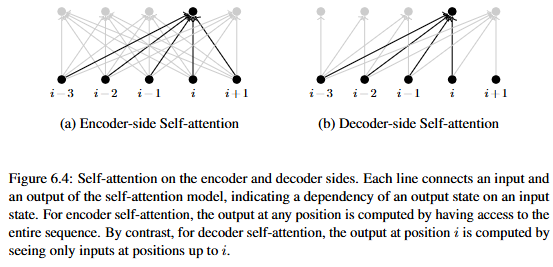

**So sánh hai loại self-attention:**

| | Encoder Self-attention | Decoder Self-attention |
|---|---|---|
| **Nhìn được** | Toàn bộ chuỗi | Chỉ $y_1\ldots y_i$ (trái) |
| **Masking** | Không | Causal mask $M$ |
| **Mục đích** | Contextualize mọi từ | Autoregressive generation |

---

## 6.1.7 Training và Inference

### Learning Rate Scheduling — Warmup + Decay

$$\eta = \eta_0 \cdot \min\!\left\{n_{\text{step}}^{-0.5},\ n_{\text{step}} \cdot n_{\text{warmup}}^{-1.5}\right\} \tag{6.48}$$

- $n_{\text{step}} < n_{\text{warmup}}$: $\eta$ tăng tuyến tính (warmup phase)
- $n_{\text{step}} > n_{\text{warmup}}$: $\eta$ giảm theo inverse square root
- Optimizer: **Adam** ($\beta_1 = 0.9$, $\beta_2 = 0.98$, $\varepsilon = 10^{-9}$)

**Lý do cần warmup:** Lúc đầu tham số ngẫu nhiên, gradient không đáng tin → LR nhỏ để ổn định. Sau đó tăng tốc khi model đã có hướng tốt, rồi decay tinh chỉnh.

### Batching và Padding

Training với minibatch — ghép nhiều chuỗi vào ma trận, thêm **padding** `□` vào cuối chuỗi ngắn:

```
A B C D E F
M N □ □ □ □
R S T □ □ □
W X Y Z □ □
```

- Padding = zero vector → không ảnh hưởng đến kết quả
- Cho phép **tensor operations song song** trên toàn batch → tận dụng GPU

### KV Cache trong Inference

**Vấn đề:** Tại mỗi bước decode $i$, attention phải tính lại cho **tất cả** vị trí $1\ldots i$ → lãng phí vì $h_1\ldots h_{i-1}$ đã tính rồi.

**Giải pháp — KV Cache:**

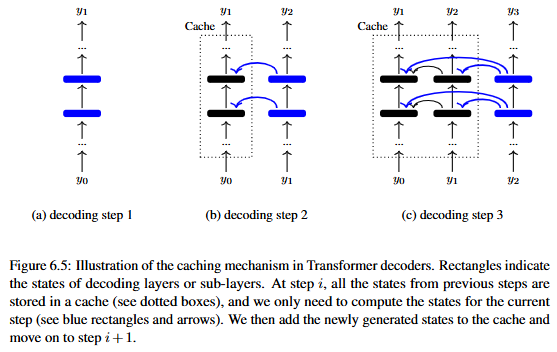

- Lưu keys $K$ và values $V$ của tất cả vị trí đã xử lý vào cache
- Tại bước $i$: chỉ tính key/value của $y_i$, tra cứu cache cho $y_1\ldots y_{i-1}$
- Giảm complexity từ $O(n^2)$ về $O(n)$ cho inference

---

## Tổng Kết Mục 6.1

```
Transformer Architecture:
  Input = Word Embedding + Sinusoidal PE
  
  Encoder Layer (×L):
    H → [Self-Attn → Add+LNorm] → [FFN → Add+LNorm] → H'
  
  Decoder Layer (×L):
    S → [Masked Self-Attn → Add+LNorm]
      → [Cross-Attn(H^L) → Add+LNorm]
      → [FFN → Add+LNorm] → S'
  
  Output: Softmax(S^L · W_o)

Các thành phần chi tiết:
  Layer Norm: LNorm(h) = α⊙(h-μ)/(σ+ε) + β
  Post-norm: LNorm(F(H)+H)  vs  Pre-norm: F(LNorm(H))+H
  FFN: ReLU(HWh+bh)Wf+bf, dffn = 4d
  Cross-attention: Q=decoder, K=V=encoder
  Masked self-attention: M(i,j) = -∞ nếu j>i

Training/Inference:
  Adam + warmup+decay LR schedule
  Padding cho batching
  KV Cache cho inference hiệu quả
```

| Thành phần | Tác dụng | Đặc điểm kỹ thuật |
|---|---|---|
| Layer Norm | Ổn định training | Chuẩn hóa theo chiều d, post/pre-norm |
| FFN ($d_{\text{ffn}}=4d$) | Non-linearity mạnh | Chiếm đa số tham số |
| Causal mask | Autoregressive generation | $M(i,j)=-\infty$ khi $j>i$ |
| KV Cache | Inference hiệu quả | Cache K,V → tránh tính lại |
| Warmup+decay | Training ổn định | LR tăng rồi giảm inverse sqrt |

# 6.2 Mô Hình Nhận Thức Cú Pháp (Syntax-aware Models)

---

## Động Lực

Transformer không dùng cấu trúc ngôn ngữ tường minh — nhưng đôi khi cần tích hợp kiến thức ngôn ngữ học (parse trees, POS tags) để cải thiện hiệu suất. Mục này trình bày các cách đưa cú pháp vào Transformer.

---

## 6.2.1 Input và Output Nhận Thức Cú Pháp

### Cách 1 — Tag Embedding

Mỗi từ $x_j$ được gán $\kappa$ nhãn cú pháp $\{\text{tag}_j^1,\ldots,\text{tag}_j^\kappa\}$ (POS, dependency labels). Embedding kết hợp:

$$e(x_j/\text{tag}_j^1/\ldots/\text{tag}_j^\kappa) = x_j + e(\text{tag}_j^1) + \ldots + e(\text{tag}_j^\kappa) \tag{6.51}$$

Hoặc qua FFN:

$$e(\cdot) = \text{FFN}_{\text{embed}}(x_j, e(\text{tag}_j^1), \ldots, e(\text{tag}_j^\kappa)) \tag{6.52}$$

### Cách 2 — Tree Linearization

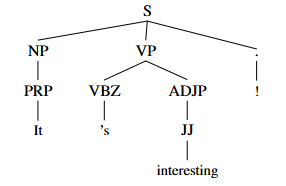

Biểu diễn cây cú pháp thành chuỗi ký hiệu qua tree traversal:

```
Câu: "It's interesting!"
Parse tree linearized:
(S (NP (PRP It)) (VP (VBZ 's) (ADJP (JJ interesting))) (. !))
```

Chuỗi này trở thành input bình thường của encoder.

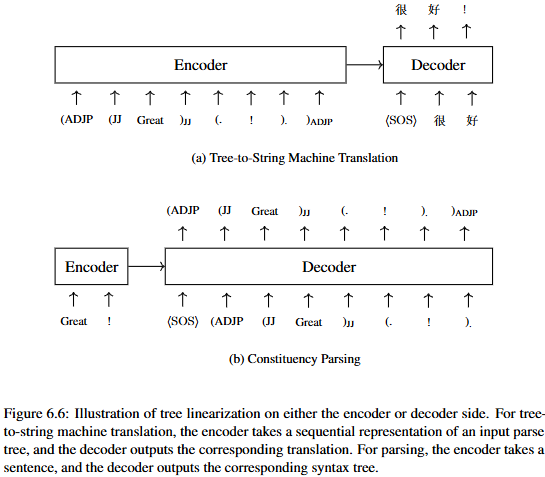

**Ứng dụng:**
- **Tree-to-string MT:** Input là cây cú pháp ngôn ngữ nguồn → output là chuỗi ngôn ngữ đích
- **Parsing:** Input là câu → output là chuỗi cây cú pháp (seq2seq parsing)

---

## 6.2.2 Mô Hình Attention Nhận Thức Cú Pháp

**Ý tưởng:** Dùng parse tree để hướng dẫn attention — hai từ có quan hệ cú pháp gần → attention weight lớn hơn.

**Attention với additive mask:**

$$\text{Att}_{\text{self}}^{\text{Syn}}(H) = \text{Softmax}\!\left(\frac{H^q [H^k]^\top}{\sqrt{d}} + M\right) H^v \tag{6.53}$$

hoặc **multiplicative mask:**

$$\text{Att}_{\text{self}}^{\text{Syn}}(H) = \text{Softmax}\!\left(\frac{H^q [H^k]^\top}{\sqrt{d}} \odot M\right) H^v \tag{6.54}$$

$M \in \mathbb{R}^{m \times m}$: giá trị lớn = tương quan cú pháp mạnh.

### Hai Cách Xây Dựng M

**0-1 Masking (Hard):**

$$M(i,j) = \begin{cases}1 & \omega(i,j) \leq \omega_{\max} \\ 0 & \text{otherwise}\end{cases} \tag{6.55}$$

$\omega(i,j)$ = shortest path length giữa hai từ trong parse tree. Chỉ cho phép attention giữa các từ có quan hệ cú pháp gần.

**Soft Masking:**

$$M(i,j) = \text{DNorm}(\omega(i,j)) \tag{6.56}$$

Attention giảm dần khi khoảng cách cú pháp tăng. Có thể dùng xác suất từ parser:

$$M(i,j) = \Pr_{\text{parent}}(i|j) \tag{6.57}$$

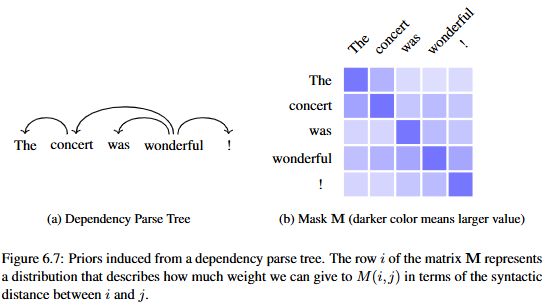

---

## 6.2.3 Mô Hình Đa Nhánh (Multi-branch Models)

**Ý tưởng:** Thay vì kết hợp cú pháp và từ vào một mô hình duy nhất, dùng **hai encoder riêng biệt** rồi kết hợp.

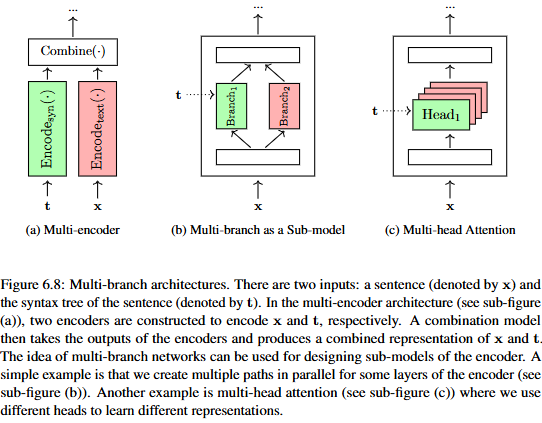

**Multi-encoder:**

$$H_{\text{hybrid}} = \text{Combine}(H_{\text{syn}}, H_{\text{text}}) = \text{Combine}(\text{Enc}_{\text{syn}}(t), \text{Enc}_{\text{text}}(x)) \tag{6.59}$$

$\text{Combine}(\cdot)$: pooling (classification), self-attention trên $[H_{\text{syn}}, H_{\text{text}}]$ (MT), v.v.

**Multi-branch sub-model** — kết hợp tuyến tính hai nhánh attention:

$$H_{\text{self}} = \alpha \cdot \text{Att}_{\text{self}}(H) + (1-\alpha) \cdot \text{Att}_{\text{self}}^{\text{Syn}}(H) \tag{6.60}$$

**Multi-head với syntax** — chỉ một số heads dùng syntax tree, phần còn lại standard.

---

## 6.2.4 Mô Hình Đa Tỷ Lệ (Multi-scale Models)

**Ý tưởng:** Encode câu ở nhiều mức độ trừu tượng:

```
Câu: "The oldest beer-making facility was discovered in China."
Words:   The oldest beer-making facility was discovered in China .  (9 tokens)
Phrases: [The oldest beer-making facility]NP [was discovered in China]VP [.]  (3 tokens)
```

Hai encoder riêng cho word-level và phrase-level → kết hợp theo dạng (6.59).

**Thách thức:** Representations của hai scales có kích thước khác nhau ($9 \times d$ vs $3 \times d$) → cần upsampling/downsampling trước khi kết hợp.

---

## 6.2.5 Transformer như Người Học Cú Pháp

**Câu hỏi:** Transformer có học được cú pháp ngầm không, khi chỉ train trên dữ liệu thô?

**Phương pháp Probing:**

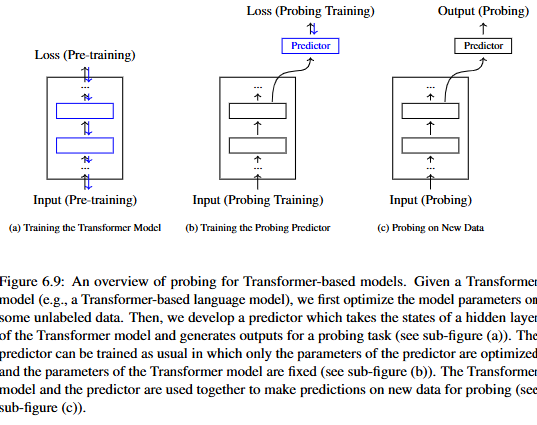

**Quy trình:**
1. Train Transformer trên unlabeled data (pre-training)
2. Đóng băng Transformer, train **probing predictor** nhỏ trên labeled data
3. Đánh giá predictor — nếu tốt → Transformer đã học được thông tin đó ngầm

**Các loại probing phổ biến:**

**Trees** — Từ attention weights tính khoảng cách cú pháp:

$$d_s(i,j) = 1 - \alpha(i,j) \tag{6.61}$$

Xây minimum-spanning tree → so sánh với human-annotated parse tree.

Học distance metric từ representations:

$$d_s^2(i,j) = \|(h_i - h_j)A\|_2^2 \tag{6.62}$$

**Syntactic/Semantic Labels** — Edge probing: cho tuple (span1, span2, label), dự đoán label. Dùng cho POS tagging, dependency parsing, coreference resolution.

**Surface Forms** — Dự đoán độ dài câu, thứ tự từ, morphology từ representations.

**Cloze/Knowledge** — Test kiến thức thực tế:

```
"Shiji was written by ___."  → "Sima Qian"
```

Transformer lớn như knowledge base ngầm.

---

## Tổng Kết Mục 6.2

```
Tích hợp cú pháp vào Transformer:

1. Input/Output:
   - Tag embedding: ej = xj + e(tag¹j) + ... + e(tagᵏj)
   - Tree linearization: cây → chuỗi → input thông thường

2. Syntax-aware Attention:
   - Mask M từ parse tree
   - 0-1 (hard): M(i,j)=1 nếu ω(i,j)≤ωmax
   - Soft: M(i,j) tỷ lệ nghịch với ω(i,j)

3. Multi-branch:
   - Multi-encoder: hai encoder riêng → Combine
   - Multi-branch: kết hợp tuyến tính hai nhánh attention
   - Multi-head: một số heads dùng syntax

4. Probing:
   - Freeze Transformer → train predictor nhỏ
   - Kiểm tra: parse trees, POS, coreference, factual knowledge
```

| Phương pháp | Tích hợp cú pháp tại | Ưu điểm | Nhược điểm |
|---|---|---|---|
| Tag embedding | Input | Đơn giản | Parse errors lan truyền |
| Syntax attention mask | Attention weights | Trực tiếp | Phụ thuộc parser chất lượng |
| Multi-encoder | Architecture | Linh hoạt | Tốn kém hơn |
| Probing | Phân tích | Không cần thay đổi model | Chỉ là analysis, không cải thiện model |

# 6.3 Các Kiến Trúc Cải Tiến (Improved Architectures)

---

## 6.3.1 Mô Hình Chú Ý Cục Bộ (Locally Attentive Models)

**Vấn đề của global attention:** Self-attention nhìn toàn bộ chuỗi — tốt cho phụ thuộc tầm xa nhưng không mô hình hóa tường minh thông tin cục bộ.

### 1. Prior cho Local Modeling

Thêm **penalty matrix** $G$ vào attention để phạt các cặp vị trí xa nhau:

**Additive penalty:**

$$\text{Att}_{\text{self}}^{\text{local}}(H) = \text{Softmax}\!\left(\frac{H^q[H^k]^\top}{\sqrt{d}} - \gamma \cdot G\right) H^v \tag{6.64}$$

Các dạng $G(i,j)$:
- **Linear:** $G(i,j) = |i-j|$ — phạt tuyến tính theo khoảng cách
- **Gaussian:** $G(i,j) = \frac{(i-j)^2}{2\sigma_i^2}$ — phạt mũ, tập trung quanh vị trí $i$

**Linear combination:**

$$\text{Att}_{\text{self}}^{\text{local}}(H) = \left[(1-\beta)\cdot\text{Softmax}\!\left(\frac{H^qH^{k\top}}{\sqrt{d}}\right) + \beta\cdot\text{Softmax}(-\gamma G)\right]H^v \tag{6.69}$$

### 2. Local Attention (Hard Constraint)

Giới hạn cứng phạm vi attention — chỉ attend trong cửa sổ $[i-k, i+k]$. Kết hợp CNN (local) + Transformer (global) vào two-branch model.

### 3. Relative Positional Embedding (RPR)

**Ý tưởng:** Thay vì mã hóa vị trí tuyệt đối, mã hóa **khoảng cách tương đối** giữa hai vị trí.

$$\text{PE}(i,j) = u_{\text{clip}(j-i,\ k_{\text{rpr}})} \tag{6.71}$$

$$\text{clip}(x, k) = \max\{-k, \min\{x, k\}\} \tag{6.72}$$

Ma trận tham số: $U_{\text{rpr}} \in \mathbb{R}^{(2k_{\text{rpr}}+1)\times d}$ — mỗi hàng là embedding cho một khoảng cách.

**Output tại vị trí $i$:**

$$c_i = \sum_{j=1}^m \alpha_{i,j}[h_j^v + \text{PE}^v(i,j)] \tag{6.74}$$

**Attention weight với RPR:**

$$\alpha_{i,j} = \text{Softmax}\!\left(\frac{[h_i^q + \text{PE}^q(i,j)][h_j^k + \text{PE}^k(i,j)]^\top}{\sqrt{d}}\right) \tag{6.75}$$

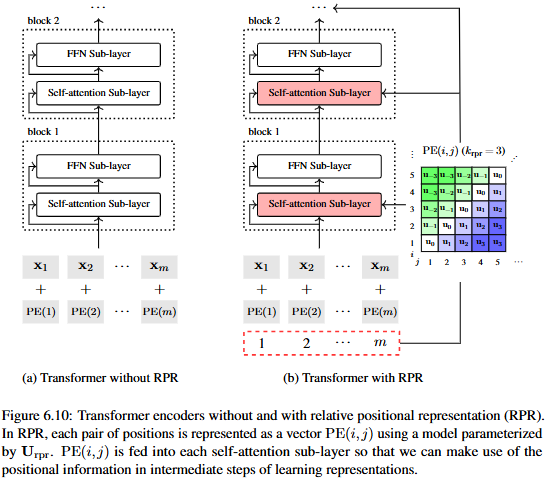

**Ưu điểm RPR:** Tổng quát hóa tốt hơn sang chuỗi dài hơn training, mô hình hóa tốt hơn ngữ cảnh cục bộ qua clipping.

---

## 6.3.2 Mô Hình Sâu (Deep Models)

### 1. Post-norm vs Pre-norm — Phân Tích Gradient

**Post-norm gradient:**

$$\frac{\partial E}{\partial z_l} = \frac{\partial E}{\partial z_L} \cdot \prod_{k=l}^{L-1}\frac{\partial\text{LNorm}(v_k)}{\partial v_k} \cdot \prod_{k=l}^{L-1}\!\left(1 + \frac{\partial F_k(z_k)}{\partial z_k}\right) \tag{6.79}$$

Tích $\prod_{k=l}^{L-1}\frac{\partial\text{LNorm}}{\partial v_k}$ gồm $L-l$ nhân tử → gradient bị rescale $L-l$ lần → **risk vanishing/exploding tăng với depth**.

**Pre-norm gradient:**

$$\frac{\partial E}{\partial z_l} = \frac{\partial E}{\partial z_L} + \frac{\partial E}{\partial z_L}\cdot\sum_{k=l}^{L-1}\frac{\partial F_k(\text{LNorm}(z_k))}{\partial z_k} \tag{6.80}$$

Số hạng đầu $\frac{\partial E}{\partial z_L}$ **độc lập với độ sâu** → gradient luôn có đường đi trực tiếp → **ổn định hơn với mạng sâu**.

**Framework thống nhất:**

$$z_l = \text{LNorm}(F_l(z_{l-1}) + \beta \cdot z_{l-1}) + \gamma \cdot z_{l-1} \tag{6.81}$$

- $\beta=1, \gamma=0$: Post-norm
- $\beta=0, \gamma=1$: Pre-norm
- $\beta, \gamma$ học được: kiến trúc linh hoạt

| | Post-norm | Pre-norm |
|---|---|---|
| **Gradient flow** | Kém với L lớn | Tốt (đường đi trực tiếp) |
| **Biểu diễn** | Mạnh hơn (nhiều phi tuyến) | Phụ thuộc residual nhiều |
| **Train stability** | Cần warmup cẩn thận | Dùng được LR lớn hơn sớm |
| **Dùng trong** | BERT | GPT-3, LLaMA |

### 2. Khởi Tạo Tham Số cho Mô Hình Sâu

**Xavier initialization chuẩn:**

$$\eta = \text{gain} \cdot \sqrt{\frac{6}{d_{\text{in}} + d_{\text{out}}}}, \quad W \sim \mathcal{U}(-\eta, \eta) \tag{6.82, 6.83}$$

**Điều chỉnh gain theo độ sâu** — mô hình sâu hơn cần giá trị khởi tạo lớn hơn:

$$\text{gain} = a \cdot L^b \tag{6.85}$$

**Điều chỉnh gain theo vị trí sub-layer** — sub-layer gần output → gain nhỏ hơn (gradient lớn hơn):

$$\text{gain} = \frac{a}{l^b} \tag{6.86}$$

$l$ = độ sâu của sub-layer; sub-layer gần input (l nhỏ) → gain lớn → tham số lớn hơn → bù đắp gradient nhỏ.

### 3. Layer Fusion (Dense Connections)

Thay vì mỗi sub-layer chỉ nhận input từ sub-layer ngay trước, nhận từ **tất cả sub-layers trước**:

$$Z_l = \phi(F_l(z_{l-1}), z_1, \ldots, z_{l-1}) \tag{6.91}$$

**Hàm fusion $\phi$:**

| Dạng | Công thức |
|---|---|
| Average Pooling | $\frac{1}{l-1}\sum_{k=1}^{l-1} z_k$ |
| Weighted Sum | $\sum_{k=1}^{l-1} w_k \cdot z_k$ |
| FFN | $\text{FFN}([z_1,\ldots,z_{l-1}])$ |
| Self-attention | $\text{FFN}([\text{Att}_{\text{self}}(z_1,\ldots,z_{l-1})])$ |

**Kết nối với linear multi-step ODE methods:** Dense connections = thuật toán bước nhiều (multi-step) cho ODE.

### 4. Regularization cho Deep Transformers

**Layer/Sub-layer Dropout** — ngẫu nhiên skip sub-layers trong training:

$$z_l = \rho \cdot \text{LNorm}(F_l(z_{l-1})) + z_{l-1} \tag{6.95}$$

Giữ sub-layer với xác suất $\rho$ → train ensemble $2^L$ sub-networks dùng chung tham số.

**Parameter Sharing** — dùng cùng tham số cho tất cả sub-layers tương ứng → giảm memory, regularization tự nhiên.

---

## 6.3.3 Mô Hình Lấy Cảm Hứng từ Phương Trình Vi Phân (ODE-inspired Models)

**Kết nối Residual Network ↔ ODE:**

Pre-norm sub-layer:

$$z_l = F_l(\text{LNorm}(z_{l-1})) + z_{l-1} \tag{6.78}$$

Tổng quát hóa:

$$z(l) = \Delta l \cdot f(z(l-\Delta l), l) + z(l-\Delta l) \tag{6.98}$$

Lấy giới hạn $\Delta l \to 0$:

$$\frac{dz(l)}{dl} = f(z(l), l) \tag{6.100}$$

→ **Pre-norm sub-layer = Euler discretization của ODE!**

**Runge-Kutta Transformer (RK4):**

$$z(l) = z(l-1) + \frac{1}{6}(g_1 + 2g_2 + 2g_3 + g_4) \tag{6.106}$$

$$g_1 = f(z(l-1)), \quad g_2 = f\!\left(z(l-1)+\frac{1}{2}g_1\right)$$
$$g_3 = f\!\left(z(l-1)+\frac{1}{2}g_2\right), \quad g_4 = f(z(l-1)+g_3)$$

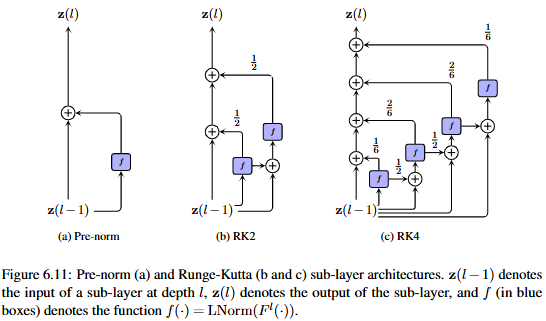

**Ưu điểm RK4 Transformer:** Mô hình sâu hơn (4 lần gọi $f$ mỗi sub-layer) mà **không tăng tham số** — tái sử dụng cùng $f(·) = \text{LNorm}(F_l(·))$.

---

## 6.3.4 Mô Hình Rộng (Wide Models)

### Tăng Chiều $d$

Tăng $d$ → model capacity tăng, nhưng:
- **Tham số:** tăng tuyến tính với $d$
- **Time complexity:** tăng bậc hai với $d$ (xem Table 6.1)

**Model Growth** — mở rộng dần thay vì train từ đầu:

$$W_2 = \underbrace{\begin{pmatrix}W_1/\rho & \cdots & W_1/\rho \\ \vdots & & \vdots \\ W_1/\rho & \cdots & W_1/\rho\end{pmatrix}}_{k \text{ times}} \in \mathbb{R}^{kd_1 \times kd_1} \tag{6.111}$$

Khởi tạo $W_2$ từ $W_1$ đã train → tiết kiệm chi phí train từ đầu.

### Mixture of Experts (MoE)

**Vấn đề:** FFN layer chiếm phần lớn tham số khi $d$ lớn → vượt quá memory thiết bị đơn.

**Giải pháp — MoE:** Thay một FFN lớn bằng $M$ FFN nhỏ (experts), chỉ kích hoạt $k$ experts mỗi lần:

**Gating model:**

$$g(h_{\text{in}}) = \text{Softmax}(h_{\text{in}} \cdot W_g) \tag{6.114}$$

**Top-k routing:**

$$h_{\text{out}} = \sum_{i \in \pi} g_i(h_{\text{in}}) \cdot \text{FFN}_i(h_{\text{in}}) \tag{6.115, 6.118}$$

$\pi$ = chỉ số $k$ experts được chọn.

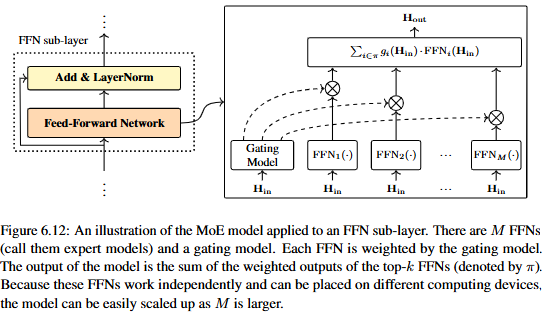

**Ưu điểm MoE:**
- Phân tán experts sang nhiều thiết bị → xử lý song song
- Mỗi forward pass chỉ dùng $k$ experts → hiệu quả tính toán
- **Sparse activation** — tổng tham số lớn nhưng tham số **active** nhỏ
- Dùng trong: GPT-MoE, Switch Transformer, Mixtral

---

## Tổng Kết Mục 6.3

```
Locally Attentive:
  Penalty matrix G → phạt attention xa
  Local attention → hard window constraint
  RPR: PE(i,j) = u_{clip(j-i, k)} → relative distance

Deep Models:
  Pre-norm > Post-norm cho gradient flow
  Unified: zl = LNorm(Fl(zl-1) + β·zl-1) + γ·zl-1
  Initialization: gain = a/l^b (sensitive to layer position)
  Dense connections: fuse outputs từ tất cả sub-layers trước
  Layer dropout: skip sub-layers ngẫu nhiên

ODE-inspired:
  Residual = Euler discretization của ODE
  RK4: 4 lần gọi f(·) → deep hơn, không thêm tham số

Wide Models:
  Model growth: mở rộng W dần từ W nhỏ đã train
  MoE: M experts, top-k routing → sparse activation
       hout = Σ_{i∈π} gi(hin)·FFNi(hin)
```

| Kỹ thuật | Mục đích | Key idea |
|---|---|---|
| RPR | Local + position-aware | $\text{PE}(i,j)$ cho từng cặp vị trí |
| Pre-norm | Stable deep training | Gradient không bị rescale nhiều lần |
| Layer dropout | Regularization | Skip sub-layers ngẫu nhiên |
| RK4 | Deeper without more params | Tái sử dụng $f(·)$ 4 lần |
| MoE | Scale width efficiently | Chỉ activate k/M experts |

# 6.4 Các Mô Hình Hiệu Quả (Efficient Models)

**Hai chiều hiệu quả cần xét:**
- **Time & Space:** Model nhỏ, nhanh, độ chính xác vẫn cao
- **Scalability:** Chi phí tăng thêm tối thiểu khi bài toán lớn hơn

**Vấn đề cốt lõi:** Self-attention có độ phức tạp $O(n^2)$ theo chiều dài chuỗi → nghẽn cổ chai cho chuỗi dài.

---

## 6.4.1 Sparse Attention

### Bài Toán

$$\text{Att}_{\text{self}}(S) = AV, \quad A = \text{Softmax}\!\left(\frac{QK^\top}{\sqrt{d}} + M\right) \tag{6.119, 6.120}$$

$A$ là ma trận $n \times n$ → memory $O(n^2)$, time $O(n^2 d)$.

**Ý tưởng sparse attention:** Chỉ tính attention với subset vị trí $\pi_i$ thay vì toàn bộ:

$$A'(i,j) = \begin{cases}a_{i,j} & j \in \pi_i \text{ và } j \leq i \\ 0 & \text{otherwise}\end{cases} \tag{6.121}$$

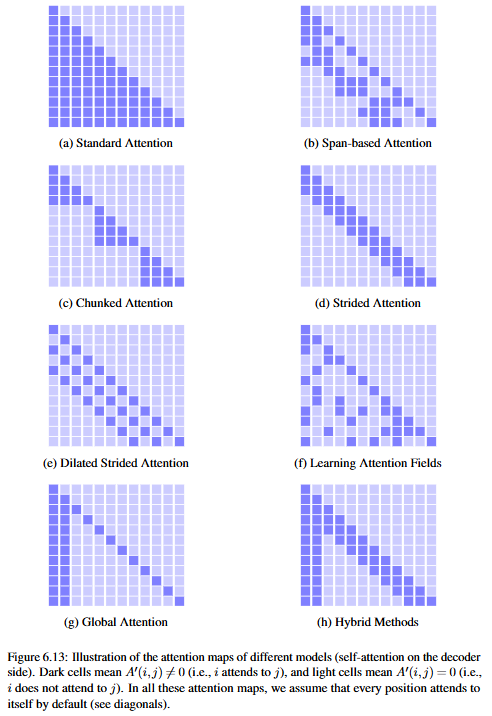

### Các Phương Pháp Sparse Attention

**Span-based / Local Attention:** $\pi_i = [a_i^l, a_i^r]$ — chỉ attend trong cửa sổ cục bộ cố định.

**Chunked Attention:** Chia chuỗi thành chunks không chồng lên nhau, attention chỉ trong chunk. Đơn giản nhưng mất quan hệ giữa chunks.

**Strided Attention:** Cửa sổ trượt với stride — các chunks chồng nhau. Stride = 1 → overlap tối đa. Dilated strided: cửa sổ không liên tục, bỏ một số vị trí.

**Learning Attention Fields:** Học $\pi_i$ từ dữ liệu. Dùng clustering (k-means trên keys/queries) hoặc hashing để nhóm các vị trí tương đồng.

**Hybrid Methods:** Kết hợp nhiều pattern:
- Local attention + Global attention + Random attention (BigBird)
- Mỗi head dùng sparse pattern khác nhau

> **Hạn chế thực tế:** Sparse models lý thuyết giảm FLOPS nhưng trên GPU/CPU thực tế chậm hơn dense operations do hardware không tối ưu cho sparsity → chủ yếu hữu ích cho **memory** hơn là tốc độ thuần túy.

---

## 6.4.2 Mô Hình Hồi Quy và Bộ Nhớ

### Transformer như Memory System

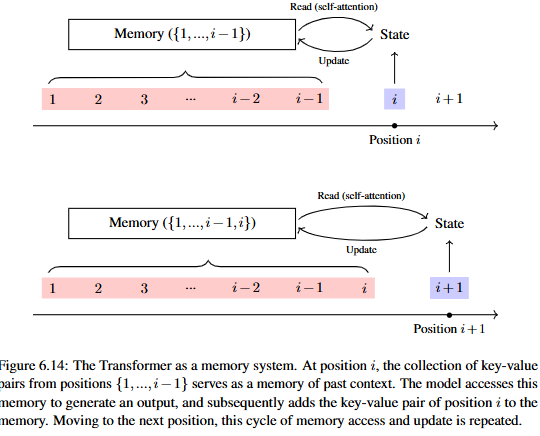

**Cache-based Memory:** Giới hạn memory bằng **context window $n_c$** — chỉ giữ $n_c-1$ vị trí gần nhất. Với $L$ layers: context window hiệu quả = $L(n_c-1)$.

### Transformer-XL

**Vấn đề chunked training:** Mỗi chunk độc lập → mất quan hệ giữa chunks.

**Giải pháp:** Cho chunk $k$ attend vào chunk $k-1$:

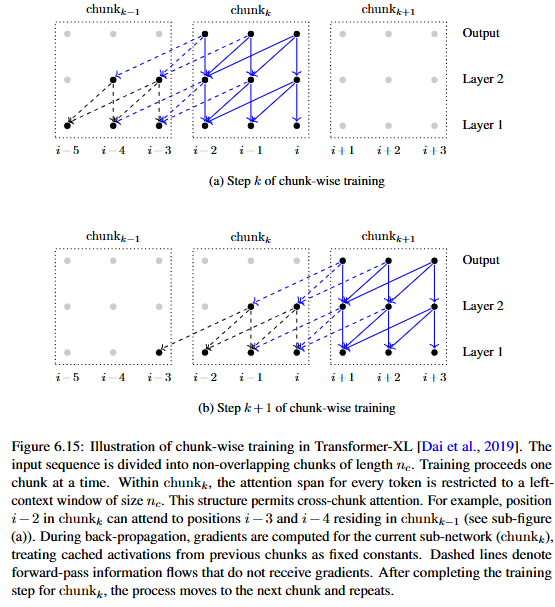

**Đặc điểm Transformer-XL:**
- Training chunk-wise, không slide window từng bước
- Activation của chunk $k-1$ được **cache** và coi là hằng số (không backprop qua đó)
- Kết hợp với **RPR** (Mục 6.3.1) để xử lý vị trí tương đối giữa chunks

---

## 6.4.3 Low-rank và Kernel Methods

**Vấn đề:** Ma trận attention $A = \text{Softmax}(QK^\top/\sqrt{d})$ kích thước $n \times n$.

**Ý tưởng low-rank:** Xấp xỉ $A \approx \hat{Q}\hat{K}^\top$ với $\hat{Q} \in \mathbb{R}^{n \times r}$, $\hat{K} \in \mathbb{R}^{n \times r}$, $r \ll n$ → giảm từ $O(n^2)$ xuống $O(nr)$.

**Linformer:** Project keys và values xuống chiều thấp $r$:

$$E = K^\top P_E^\top, \quad F = V^\top P_F^\top$$

với $P_E, P_F \in \mathbb{R}^{r \times n}$ là projection matrices. Attention trở thành $O(nr)$.

**Kernel-based attention:** Thay $\text{Softmax}(QK^\top)$ bằng kernel function:

$$A(i,j) = \phi(q_i)^\top \phi(k_j)$$

Với $\phi$ phù hợp, tính $((\phi(Q)\phi(K)^\top)V)$ theo thứ tự khác: $\phi(Q)(\phi(K)^\top V)$ → $O(nd^2)$ thay vì $O(n^2 d)$.

---

## 6.4.4 Parameter Sharing và Lightweight Architectures

**Parameter sharing:**
- Dùng cùng tham số cho tất cả layers (Universal Transformer)
- Giảm memory footprint đáng kể, có tác dụng regularization

**Lightweight attention:**
- Giảm số heads $\tau$ hoặc chiều $d$
- Factorize attention matrices

**Efficient FFN:**
- Giảm $d_{\text{ffn}}$ (thay $4d$ bằng $d$ hoặc $2d$)
- Dùng depthwise separable convolution thay FFN

---

## 6.4.5 Non-autoregressive Models

**Autoregressive generation** (standard): Sinh từng từ tuần tự → $O(n)$ bước, mỗi bước attend vào toàn bộ prefix → chậm.

**Non-autoregressive (NAR):** Sinh **tất cả từ song song** trong một lần:

$$\Pr(y|x) \approx \prod_{i=1}^n \Pr(y_i|x)$$

**Ưu điểm:** Cực kỳ nhanh trong inference (tất cả vị trí tính song song).

**Nhược điểm:** Bỏ qua phụ thuộc giữa các từ target → chất lượng kém hơn AR. Cần kỹ thuật đặc biệt như:
- **Fertility prediction:** Predict bao nhiêu từ target mỗi từ source sinh ra
- **Iterative refinement:** Sinh draft → refine nhiều lần
- **Masked language model decoding:** Predict từ bị mask, lặp lại

---

## 6.4.6 Conditional Computation (Adaptive Depth)

**Ý tưởng:** Không phải mọi input đều cần cùng số layers — input dễ cần ít layers hơn input khó.

**Early Exit** — thêm classifier tại mỗi layer:

$$p_i^l = \text{Softmax}(s_i^l \cdot W_o^l) \tag{6.184}$$

Train $L-1$ classifier phụ, mỗi classifier tại hidden state layer $l$.

**Điều kiện exit:**
- Entropy của $p_i^l$ thấp (model tự tin)
- Max probability cao
- $p_i^l$ và $p_i^{l-1}$ rất giống nhau (prediction đã hội tụ)
- Hidden state $s_i^l \approx s_i^{l-1}$

**Layer Skipping:** Tổng quát hơn early exit — chọn bất kỳ subset layers nào để dùng.

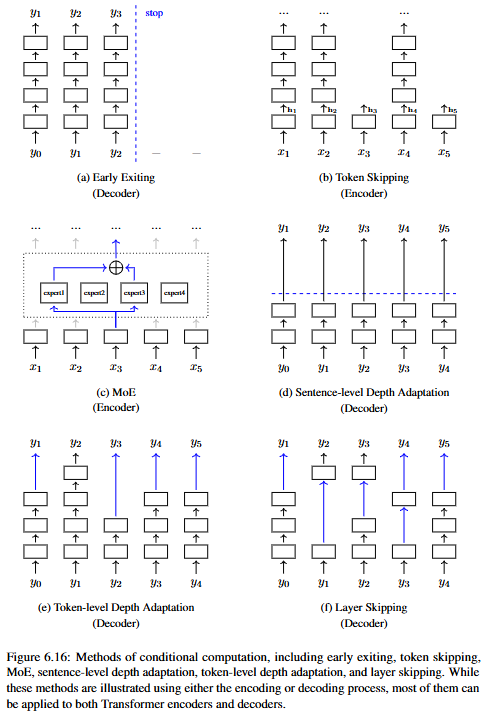

---

## 6.4.7 Model Transfer và Pruning

### Knowledge Distillation

**Teacher-student training:** Dùng output của teacher model lớn để train student model nhỏ.

$$L(x, \theta) = \frac{1}{n}\sum_{i=1}^n \text{Loss}(\tilde{p}_i, p_i) \tag{6.185}$$

$\tilde{p}_i$ = distribution của teacher; $p_i$ = distribution của student.

**Các biến thể:**
- Distill từ hidden states (không chỉ output probabilities)
- Relation distillation: khớp quan hệ giữa các samples
- **Sequence-level distillation:** Teacher dịch tập dữ liệu → dùng output làm labeled data train student (architecture-agnostic, black-box friendly)

### Structured Pruning

Xóa toàn bộ components thay vì từng weight:
- **Head pruning:** Xóa attention heads ít quan trọng
- **Layer pruning:** Xóa toàn bộ layers

**Đánh giá importance** của component $\theta_r$:
- Norm của weights/gradients
- Trainable gates: học xem component nào nên giữ

---

## 6.4.8 Nén Chuỗi (Sequence Compression)

**Tại sao:** Transformer $O(n^2)$ → chuỗi ngắn hơn = hiệu quả hơn nhiều.

**Các phương pháp:**

**Fixed-size encoding:** Dùng cross-attention giữa $x_1\ldots x_m$ và $r$ learnable queries $u_1\ldots u_r$ → output $r$ vectors cố định (Perceiver).

**Downsampling:**
- Strided convolution: stride 2 → giảm độ dài 2 lần
- Progressive pooling: nhiều lớp → giảm nhiều hơn

**Tokenization:** BPE vocabulary lớn → ít tokens hơn trên cùng text.

**Token Pruning:** Xóa tokens ít quan trọng dựa trên attention weights → chuỗi ngắn hơn trong inference.

---

## 6.4.9 High Performance Computing Methods

### Mixed Precision Training

Dùng **half-precision (FP16)** thay single-precision (FP32):
- Model size giảm 2×
- Computation nhanh hơn trên hardware hỗ trợ
- Không thay đổi kiến trúc, chỉ thay đổi data type

### Quantization

Ánh xạ floating-point → integer:

$$Q(x) = \lfloor x/s \rceil, \quad D(r) = s \cdot r \tag{6.186, 6.187}$$

$s$ = quantization step size; quantization error = $D(Q(x)) - x$.

**Ứng dụng:** Quantize weights và activations → integer arithmetic → nhanh hơn nhiều trên hardware.

**Post-training quantization:** Quantize sau khi đã train → đơn giản nhưng có thể mất accuracy.

**Quantization-aware training:** Train với quantization → model học bù đắp quantization error → tốt hơn.

### Kernel Fusion và FlashAttention

**Kernel fusion:** Merge nhiều operations thành một kernel → tránh memory transfer giữa GPU on-chip và off-chip memory.

**FlashAttention:** Chia attention matrix thành blocks, tính từng block giữ trong SRAM → tránh đọc/ghi $n \times n$ matrix từ HBM → tốc độ thực tế nhanh hơn nhiều dù cùng FLOPS.

---

## Tổng Kết Mục 6.4

```
Vấn đề: O(n²) attention + model lớn

Giải pháp theo hướng:

1. Sparse Attention (giảm n²):
   Local/Chunked/Strided/Learned → chỉ attend subset vị trí

2. Memory/Recurrent (xử lý chuỗi dài):
   Context window, Transformer-XL (cross-chunk)

3. Low-rank/Kernel (xấp xỉ attention):
   Linformer: project K,V xuống rank r → O(nr)
   Kernel attention: đổi thứ tự tính → O(nd²)

4. Model Compression:
   Knowledge Distillation: teacher → student
   Structured Pruning: xóa heads/layers
   Quantization: FP32 → INT8

5. Adaptive Computation:
   Early Exit: dừng sớm ở layer nào đó
   NAR: sinh song song tất cả từ

6. Hardware:
   Mixed precision: FP16
   FlashAttention: IO-aware attention
   Kernel fusion
```

| Phương pháp | Giảm gì | Trade-off |
|---|---|---|
| Sparse Attention | Memory $O(n^2)$ → $O(nk)$ | Mất long-range dependencies |
| Transformer-XL | Gradient qua chunks | Phức tạp implementation |
| Knowledge Distillation | Model size | Cần train teacher trước |
| Structured Pruning | Params + compute | Chất lượng giảm |
| Quantization | Memory + compute | Quantization error |
| Early Exit | Compute/latency | Training phức tạp hơn |
| FlashAttention | IO bandwidth | Không giảm FLOPS |

# 6.5 Các Ứng Dụng (Applications)

Transformer được dùng trong ba cấu hình chính:

| Cấu hình | Thành phần | Ứng dụng |
|---|---|---|
| **Decoder-only** | Chỉ decoder (bỏ cross-attention) | Text generation, language modeling |
| **Encoder-only** | Chỉ encoder | Classification, sequence labeling, text encoding |
| **Encoder-Decoder** | Cả hai | Machine translation, seq2seq |

---

## 6.5.1 Language Modeling

**Decoder-only LM** — bỏ cross-attention sub-layer, decoder block trở thành:

$$S^l_{\text{self}} = \text{Layer}_{\text{self}}(S^{l-1}) \tag{6.191}$$
$$S^l = \text{Layer}_{\text{ffn}}(S^l_{\text{self}}) \tag{6.190}$$

Giống hệt encoding block, **chỉ khác ở masking**: decoder dùng causal mask (không nhìn tương lai), encoder không mask.

**Inference — autoregressive:**

$$\hat{x}_{i+1} = \arg\max_{x \in V} \Pr(x \mid x_0,\ldots,x_i) \tag{6.188}$$

$$\hat{x}_{k+1} = \arg\max_{x \in V} \Pr(x \mid x_0,\ldots,x_i,\hat{x}_{i+1},\ldots,\hat{x}_k) \tag{6.189}$$

Đây là nền tảng của GPT và các large language models hiện đại.

---

## 6.5.2 Text Encoding

**Encoder-only** cho các task cần hiểu ngữ nghĩa.

**[CLS] token:** Thêm token đặc biệt $x_0 = \langle\text{CLS}\rangle$ vào đầu chuỗi. Output $h_0^L$ serve như **global sequence representation** — được attend bởi mọi vị trí khác qua self-attention.

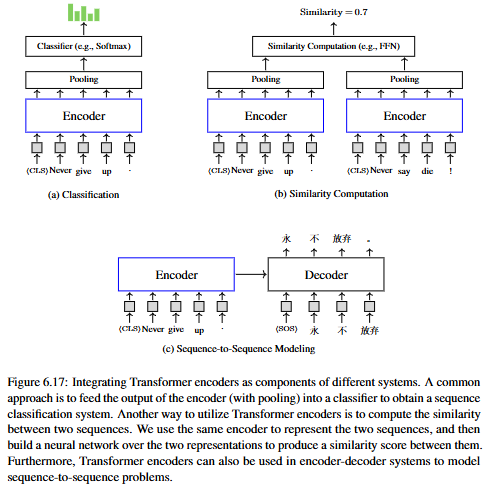

**Ba ứng dụng chính:**

**Text Classification** — dùng $h_0^L$ qua Softmax:
```
[CLS] Never give up . → Encoder → h₀ᴸ → Classifier → Label
```

**Similarity Computation** — encode hai câu, so sánh:
```
Sentence A → Encoder → h_A
Sentence B → Encoder → h_B
cosine(h_A, h_B) → similarity score
```

**Encoder-Decoder** — encoder làm text encoder, decoder sinh output.

> **Nền tảng cho BERT:** Pre-train encoder trên unlabeled data lớn → fine-tune cho downstream tasks. Chi tiết ở Chương 7.

---

## 6.5.3 Speech Translation (S2T)

**Bài toán:** Acoustic features $a_1\ldots a_m$ → text tokens $y_1\ldots y_n$ (qua biên ngôn ngữ và modality).

**Thách thức riêng của S2T so với MT:**
- Cross-modality (audio ↔ text)
- Cross-language
- Dữ liệu speech-text pair rất khan hiếm

**Ba kiến trúc encoder:**

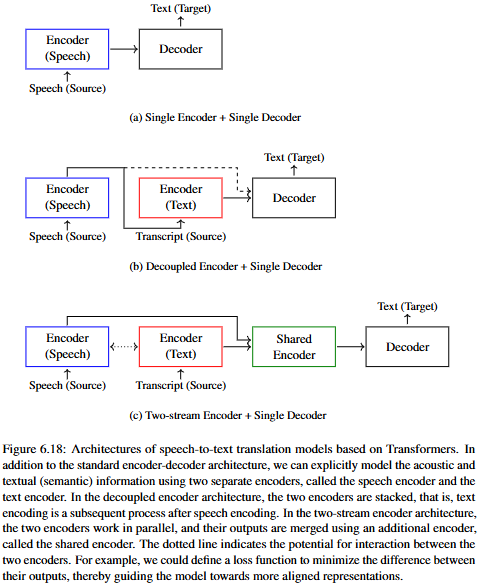

**Single Encoder + Decoder** — standard Transformer encoder-decoder, encoder đọc acoustic features.

**Decoupled Encoder** — hai encoder xếp chồng:
- **Speech encoder:** học acoustic features → language units (tương tự ASR)
- **Text encoder:** học semantic/syntactic features trên transcript
- Cho phép pre-train từng encoder riêng trên unlabeled data

**Two-stream Encoder** — hai encoder song song:
- Speech encoder: acoustic input
- Text encoder: token input (transcript)
- **Shared encoder:** merge outputs từ cả hai
- Linh hoạt: mask text encoder → S2T training; mask speech encoder → MT training
- Inference: drop text encoder, dùng speech + shared encoder

**Multi-task training:** Thêm CTC loss trên speech encoder output → train giống ASR, cải thiện speech representation.

---

## 6.5.4 Vision Transformer (ViT)

**Ý tưởng cốt lõi:** Image → sequence of patches → Transformer encoder.

**Quy trình:**

**Bước 1 — Patching:** Chia ảnh $H \times W \times C$ thành $\frac{HW}{P^2}$ patches kích thước $P \times P \times C$.

**Bước 2 — Patch Embedding:** Flatten mỗi patch → linear transform → $d$-dimensional vector + positional embedding.

**Bước 3 — Transformer Encoder:** Xử lý sequence of patch embeddings như text encoding.

**Bước 4 — Classification:** Dùng $h_0^L$ (output tại [CLS] token) → classifier.

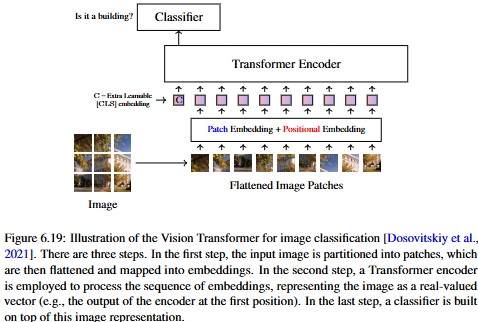

**Ý nghĩa quan trọng:** ViT thống nhất representation model cho nhiều modalities — bất kỳ object nào biểu diễn được thành **sequence of embeddings** đều có thể xử lý bằng Transformer.

---

## 6.5.5 Multimodal Models

**Ý tưởng:** Kết hợp text và image (hoặc các modality khác) vào một Transformer duy nhất.

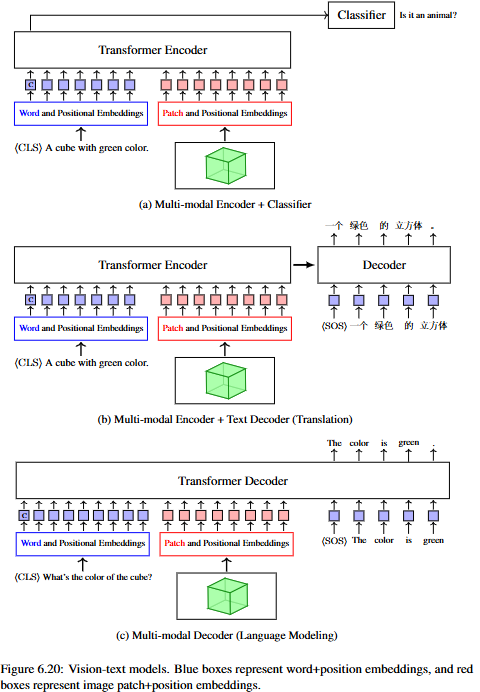

**Quy trình:**
1. Text → word embeddings (sequence of $d$-dim vectors)
2. Image → patch embeddings (sequence of $d$-dim vectors)
3. **Concatenate** hai sequences → long joint sequence
4. Transformer encoder xử lý joint sequence → fused representation

Vì cả text và image đều được biểu diễn thành sequences cùng chiều $d$, Transformer có thể học **cross-modal attention** tự nhiên — text tokens attend vào image patches và ngược lại.

**Ứng dụng:** Visual Question Answering (VQA), image captioning, text-to-image retrieval, multimodal translation.

---

## Tổng Kết Mục 6.5

```
Ba cấu hình Transformer:

Decoder-only (GPT):
  Causal self-attention only
  x₀...xᵢ → predict xᵢ₊₁
  → Language modeling, text generation

Encoder-only (BERT):
  Bidirectional self-attention
  [CLS] x₁...xm → h₀ᴸ...hmᴸ
  → Classification, similarity, NER

Encoder-Decoder (T5, BART):
  Source → Encoder → H^L
  H^L + target prefix → Decoder → next token
  → MT, summarization, S2T

Mở rộng sang các modality khác:
  Speech: acoustic features → encoder → text (S2T)
  Vision: image patches → encoder → classification (ViT)
  Multimodal: [text tokens | image patches] → joint encoder
```

| Task | Cấu hình | [CLS] | Masking |
|---|---|---|---|
| Language Modeling | Decoder-only | Không cần | Causal |
| Classification | Encoder-only | ✓ global repr | None |
| Machine Translation | Encoder-Decoder | Optional | Encoder: none; Decoder: causal |
| Speech Translation | Encoder-Decoder | Optional | Causal |
| Image Classification | Encoder-only (ViT) | ✓ | None |
| Multimodal | Encoder-only | ✓ | None |

> **Kết nối với Chương 7-8:** Các mô hình pre-trained (BERT, GPT, T5) đều dựa trên các cấu hình này. Chương 7 sẽ trình bày chi tiết cách pre-train encoder-only (BERT) và decoder-only (GPT) trên large-scale unlabeled data để tạo ra các foundation models.

# 6.6 Tổng Kết Chương 6 — Transformer

---

## Nhìn Lại: Transformer Không Phải "Hoàn Toàn Mới"

Transformer kết hợp các thành phần đã có từ trước theo cách mới:

| Thành phần | Nguồn gốc |
|---|---|
| Word/Positional Embedding | Bengio et al. 2003, Mikolov et al. 2013 |
| Attention mechanism | Bahdanau et al. 2014, Luong et al. 2015 |
| QKV attention | Memory Networks (Sukhbaatar et al. 2015) |
| Residual connections | He et al. 2016 |
| Layer Normalization | Ba et al. 2016 |

**Điểm mới của Transformer:** Kết hợp multi-head attention + dot-product QKV + Layer Norm + Residual thành **self-attention sub-layer** chuẩn hóa → de facto standard cho sequence modeling.

---

## Bức Tranh Toàn Cảnh Transformer

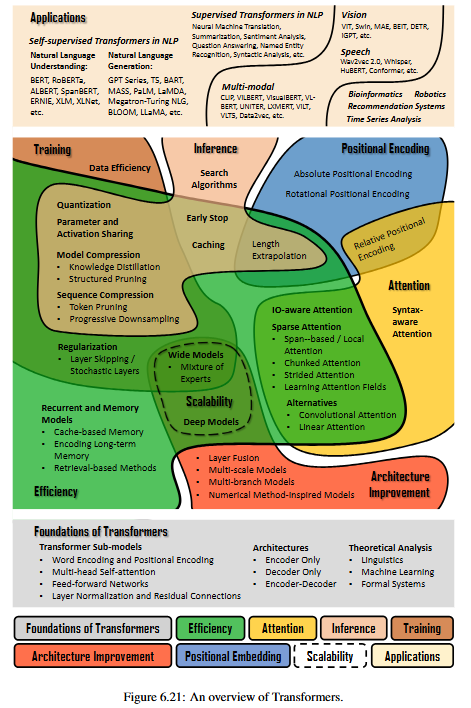

---

## Các Điểm Nổi Bật

### 1. Attention Models

**Ba hướng nghiên cứu chính:**
- **Cải tiến QKV/multi-head:** Thêm components mới vào self-attention sub-layers cho task cụ thể
- **Tích hợp prior knowledge:** Cú pháp, alignment → syntax-aware attention (Mục 6.2)
- **Efficient attention:** Giải quyết $O(n^2)$ → sparse, linear, recurrent approximations (Mục 6.4)

**Phát hiện thú vị:** Multi-head self-attention học được cấu trúc ngôn ngữ ngầm (dependency relations, POS) **mà không được training tường minh** để làm điều đó.

### 2. Positional Encoding

**Vấn đề extrapolation:** Sinusoidal PE kém khi chuỗi dài hơn training. Hai giải pháp hiện đại:
- **RoPE (Rotary Positional Embedding):** Encode vị trí qua phép quay trong không gian complex → tổng quát hóa tốt hơn
- **ALiBi:** Scale attention weights với positional bias → tự nhiên hỗ trợ chuỗi dài hơn

### 3. Training và Model Scaling

**Deep + Wide = Better:** Thêm layers và tăng $d$ → hiệu suất tốt hơn nhất quán.

**Scaling Laws:** Performance cải thiện theo power law với số tham số, dữ liệu, và compute:

$$\text{Loss} \propto N^{-\alpha} \cdot D^{-\beta} \cdot C^{-\gamma}$$

**Emergent Abilities:** Khi model đủ lớn, xuất hiện khả năng **không thể dự đoán** từ scaling — few-shot learning, chain-of-thought reasoning, code generation,...

**MoE cho scale lớn:** Sparse Mixture-of-Experts → tham số rất lớn nhưng chỉ activate k experts mỗi lần → hiệu quả tính toán.

### 4. Efficient Models

**Hai mục tiêu khác nhau:**
- **Memory-bound:** Sparse attention → giảm $n^2$ memory
- **Latency-bound:** Quantization, early exit, KV cache → giảm inference time

**IO-aware optimization (FlashAttention):** Không giảm FLOPS mà tối ưu memory access pattern → tốc độ thực tế tăng đáng kể.

**Speculative Decoding:** Dùng model nhỏ draft nhiều tokens, model lớn verify → giảm số lần gọi model lớn.

### 5. Inference / Search

Các thuật toán từ MT/ASR áp dụng trực tiếp cho Transformer generation: beam search, greedy, diverse beam, MBR (Chương 5).

### 6. Applications

**Lộ trình phát triển:**
```
Supervised Transformers
  → Pre-trained Foundation Models (BERT, GPT)
     → Fine-tuning cho downstream tasks
        → Prompting / In-context learning
           → Large Language Models (GPT-4, LLaMA,...)
```

**Mở rộng sang các domain khác:**
- **NLP:** BERT (encoder), GPT (decoder), T5/BART (encoder-decoder)
- **Vision:** ViT, Swin Transformer, MAE, DETR
- **Speech:** Wav2Vec 2.0, Whisper, HuBERT, Conformer
- **Multimodal:** CLIP, ViLBERT, DALL-E, Flamingo

**Nguyên lý thống nhất:** Mọi loại dữ liệu đều được biểu diễn thành **sequence of tokens** → cùng Transformer architecture xử lý được.

### 7. Theoretical Analysis

**Kết nối với các formal systems:**
- Residual network = **Euler discretization của ODE** → thiết kế architecture từ numerical methods
- Self-attention ↔ **data compression, optimization theory**
- Transformer ≡ **Turing machine** (về mặt expressivity)
- Mapping sang **Boolean circuits, first-order logic**

> **Thách thức còn lại:** Chưa có lý thuyết thống nhất giải thích bản chất của Transformer — hiểu tại sao scaling laws tồn tại, tại sao emergent abilities xuất hiện, v.v.

---

## Tổng Kết Toàn Chương 6

```
Transformer = Self-attention + FFN + Residual + LayerNorm + PE

Kiến trúc cơ bản:
  Encoder: [Self-Attn → Add+LN → FFN → Add+LN] × L
  Decoder: [Masked Self-Attn → Cross-Attn → FFN] × L
  Output: Softmax(S^L · W_o)

Cải tiến kiến trúc:
  RPR, Local Attention  → locality + position-aware
  Pre-norm, Deep init   → stable deep training
  MoE                   → efficient wide models
  RK4 sub-layers        → ODE-inspired depth

Efficient:
  Sparse Attention  → O(n²) → O(nk)
  Knowledge Distill → large → small model  
  Quantization      → FP32 → INT8
  FlashAttention    → IO-aware

Ba cấu hình → ba paradigm:
  Decoder-only → GPT, language generation
  Encoder-only → BERT, language understanding
  Encoder-Decoder → T5, seq2seq

Mở rộng:
  ViT: images as patches
  Multimodal: [text tokens | image patches]
  Universal: any data as token sequences
```